# Prepare Data

- Read in netcdf data from Himawari and BARRA-C2
- Regrid onto a common grid to line up datasets
- Convert into tabular format
- Save as a parquet file

In [1]:
from pathlib import Path
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import pandas as pd

from metpy.calc import dewpoint_from_specific_humidity
from metpy.units import units

import xesmf as xe

import os
import sys

sys.path.append('/home/548/cd3022/repos/solar-nowcast/modules')
import sat_preprocess
import clear_sky

In [38]:
# Time bounds to prepare data for
date = '2022-01-01'
num_days = '1'

start_year, start_month, start_day = [int(i) for i in date.split('-')]

# Data boundaries
start_date = datetime(start_year, start_month, start_day)
end_date   = datetime(start_year, start_month, start_day + int(num_days))

# Regional boundaries
lat_min=-35
lat_max=-28.5
lon_min=145
lon_max=151.5

In [30]:
def preprocess(ds):
    return ds.sel(
        lat=slice(lat_max, lat_min),
        lon=slice(lon_min, lon_max)
    )

In [ ]:
acc_g = xr.open_mfdataset(['/g/data/wr45/ops_aps3/access-g/1/20220101/0000/fc/sfc/av_swsfcdown.nc'], preprocess=preprocess)
acc_sy = xr.open_mfdataset(['/g/data/wr45/ops_aps3/access-sy/1/20220101/0000/fc/sfc/av_swsfcdown.nc'], preprocess=preprocess)

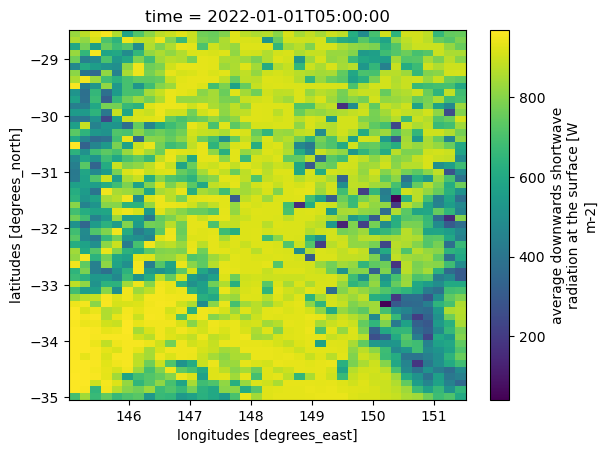

In [50]:
acc_g['av_swsfcdown'].sel(time='2022-01-01T05:00:00').plot()

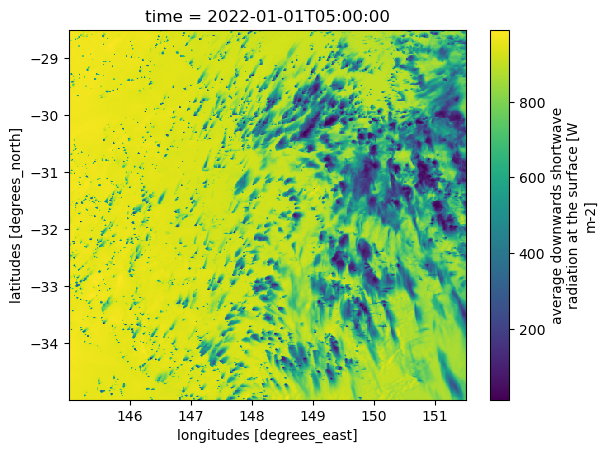

In [51]:
acc_sy['av_swsfcdown'].sel(time='2022-01-01T05:00:00').plot()

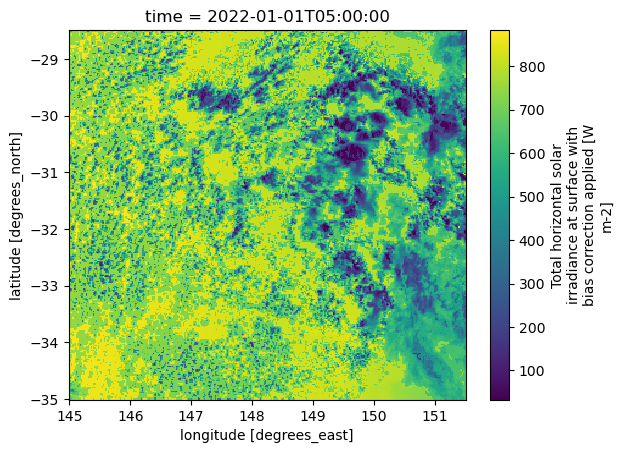

In [52]:
ghi['surface_global_irradiance'].sel(time='2022-01-01T05:00:00').plot()

In [49]:
bar

<xarray.Dataset> Size: 11MB
Dimensions:             (time: 29, lat: 59, lon: 59, bnds: 2)
Coordinates:
  * time                (time) datetime64[ns] 232B 2022-01-01 ... 2022-01-01T...
  * lat                 (lat) float64 472B -34.98 -34.87 -34.76 ... -28.71 -28.6
  * lon                 (lon) float64 472B 145.0 145.1 145.2 ... 151.3 151.4
  * bnds                (bnds) float64 16B 0.0 1.0
    level_height        float64 8B ...
    model_level_number  int32 4B ...
    sigma               float64 8B ...
    height              float64 8B ...
    crs                 int32 4B ...
    pressure            float64 8B ...
Data variables: (12/15)
    huss                (time, lat, lon) float64 808kB dask.array<chunksize=(15, 59, 59), meta=np.ndarray>
    hus850              (time, lat, lon) float64 808kB dask.array<chunksize=(15, 59, 59), meta=np.ndarray>
    hus700              (time, lat, lon) float64 808kB dask.array<chunksize=(15, 59, 59), meta=np.ndarray>
    hus500              (time, lat, lon) float64 808kB dask.array<chunksize=(15, 59, 59), meta=np.ndarray>
    psl                 (time, lat, lon) float64 808kB dask.array<chunksize=(15, 59, 59), meta=np.ndarray>
    tas                 (time, lat, lon) float64 808kB dask.array<chunksize=(15, 59, 59), meta=np.ndarray>
    ...                  ...
    rsds                (time, lat, lon) float64 808kB dask.array<chunksize=(14, 59, 59), meta=np.ndarray>
    time_bnds           (time, bnds) datetime64[ns] 464B dask.array<chunksize=(1, 2), meta=np.ndarray>
    RH24mean            (time, lat, lon) float64 808kB dask.array<chunksize=(15, 59, 59), meta=np.ndarray>
    MUEL                (time, lat, lon) float64 808kB dask.array<chunksize=(15, 59, 59), meta=np.ndarray>
    FZL                 (time, lat, lon) float64 808kB dask.array<chunksize=(15, 59, 59), meta=np.ndarray>
    MULCL               (time, lat, lon) float64 808kB dask.array<chunksize=(15, 59, 59), meta=np.ndarray>
Attributes: (12/59)
    axiom_version:             0.1.0
    axiom_schemas_version:     0.1.0
    axiom_schema:              cordex-1H.json
    productive_version:        bc7ee68
    variable_version:          v20240516
    Conventions:               CF-1.10, ACDD-1.3
    ...                        ...
    date_modified:             2024-10-11T01:43:53Z
    date_metadata_modified:    2024-10-11T01:43:53Z
    history:                   Tue May 14 09:33:03 2024: /g/data/access/ngm/m...
    references:                https://doi.org/10.25914/1x6g-2v48
    license:                   https://doi.org/10.25914/1x6g-2v48
    acknowledgement:           The production of BARRA2 was supported with fu...

In [59]:
bar['rsds'].sel(time='2022-01-01T05:00:00')

<xarray.DataArray 'rsds' (lat: 59, lon: 59)> Size: 28kB
dask.array<getitem, shape=(59, 59), dtype=float64, chunksize=(59, 59), chunktype=numpy.ndarray>
Coordinates:
  * lat                 (lat) float64 472B -34.98 -34.87 -34.76 ... -28.71 -28.6
  * lon                 (lon) float64 472B 145.0 145.1 145.2 ... 151.3 151.4
    time                datetime64[ns] 8B 2022-01-01T05:00:00
    level_height        float64 8B ...
    model_level_number  int32 4B ...
    sigma               float64 8B ...
    height              float64 8B ...
    crs                 int32 4B ...
    pressure            float64 8B ...
Attributes:
    long_name:      Surface Downwelling Shortwave Radiation
    standard_name:  surface_downwelling_shortwave_flux_in_air
    units:          W m-2
    cell_methods:   time: mean (interval: 1 hour)
    grid_mapping:   crs

In [39]:
# Get file paths for Heliosat datasets
base_path = Path('/g/data/rv74/satellite-products/arc/der/himawari-ahi/solar/p1s/latest')

files = []

current = start_date
while current < end_date:
    year  = current.year
    month = current.month
    day   = current.day

    file_path = base_path / f"{year}/{month:02d}/{day:02d}"
    
    if file_path.exists():  # important for missing days
        files.extend(file_path.rglob("*.nc"))
    
    current += timedelta(days=1)

In [40]:
# Select variables to be used from the heliosat dataset
helio_vars = [
    'surface_global_irradiance',
    'cloud_optical_depth',
    'solar_elevation',
]

# keep just the region and variables during preprocessing
def preprocess(ds):
    return ds.sel(
        latitude=slice(lat_min, lat_max),
        longitude=slice(lon_min, lon_max)
    )[helio_vars]


# Open the data
ghi = xr.open_mfdataset(files, preprocess=preprocess)

In [5]:
# ghi.cloud_optical_depth.sel(time='2024-05-31T18:30:00').plot()

In [6]:
%%time
rad_list = []

ch_list = [
    'B03',
    # 'B04',
    'B05',
    'B07',
    # 'B08',
    'B09',
    'B11',
    'B13',
    'B15'
]


for channel in ch_list:

    ds = sat_preprocess.read_himawari_channel(
        channel,
        start_date, end_date, # end_date,
        lat_min, lat_max, lon_min, lon_max,
        coords=True
    )

    rad_list.append(ds)
    print(f"{channel} DONE!")

B03 DONE!
B05 DONE!
B07 DONE!
B09 DONE!
B11 DONE!
B13 DONE!
B15 DONE!
CPU times: user 7min 52s, sys: 3min 34s, total: 11min 27s
Wall time: 11min 28s


In [7]:
# Use final radiance ds as reference for interpolation
# (if channels were listed in ascending order, should be the lowest resolution channel)
ref_ds = rad_list[-1]

interp_list = []

# interpolate radiance data to the same grid
for ds in rad_list:
    if ds.sizes != ref_ds.sizes:
        ds = ds.interp(y=ref_ds.y, x=ref_ds.x)

    # Drop conflicting coords (except for reference)
    if ds is not ref_ds:
        ds = ds.drop_vars(["latitude", "longitude"], errors="ignore")

    interp_list.append(ds)
    
# merge into single dataset
ds_rad = xr.merge(interp_list)

/jobfs/167736620.gadi-pbs/ipykernel_2200868/1822073988.py:19: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_rad = xr.merge(interp_list)
/jobfs/167736620.gadi-pbs/ipykernel_2200868/1822073988.py:19: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_rad = xr.merge(interp_list)


In [8]:
# Regrid radiances from (x, y) to (lat, lon)
regridder = xe.Regridder(
    ds_rad,
    ghi,
    method="bilinear",
    reuse_weights=False
)
ds_rad_interp = regridder(ds_rad)

/opt/conda/envs/pet/lib/python3.11/site-packages/xarray/computation/apply_ufunc.py:450: PerformanceWarning: Regridding is increasing the number of chunks by a factor of 66.0, you might want to specify sizes in `output_chunks` in the regridder call. Default behaviour is to preserve the chunk sizes from the input (5, 323).
  result_vars[name] = func(*variable_args)
/opt/conda/envs/pet/lib/python3.11/site-packages/dask/array/routines.py:333: PerformanceWarning: Increasing number of chunks by factor of 73
  intermediate = blockwise(
/opt/conda/envs/pet/lib/python3.11/site-packages/xarray/computation/apply_ufunc.py:450: PerformanceWarning: Regridding is increasing the number of chunks by a factor of 15.0, you might want to specify sizes in `output_chunks` in the regridder call. Default behaviour is to preserve the chunk sizes from the input (23, 323).
  result_vars[name] = func(*variable_args)
/opt/conda/envs/pet/lib/python3.11/site-packages/dask/array/routines.py:333: PerformanceWarning: I

In [47]:
# BARRA-R2 Data
files = []
year  = start_date.year
month = start_date.month

# STANDARD VARS
variables_of_interest = [
    # Moisture
    'huss',
    'hus850',
    'hus700',
    'hus500',
    # Wind
    # 'ua850',
    # 'va850',
    # 'wa850',
    # Pressure and geopotential
    'psl',
    # 'zg850',
    # 'zg500',
    # Temperature
    'tas',
    'ta850',
    'ta700',
    'ta500',
    # radiation
    'rsds',
]
for var in variables_of_interest:
    file_path = Path(f'/g/data/ob53/BARRA2/output/reanalysis/AUS-11/BOM/ERA5/historical/hres/BARRA-R2/v1/1hr/{var}/latest/')
    var_file = [f for f in file_path.glob(f'*{year}{month:02d}.nc')][0]
    files.append(var_file)

# CONVECTIVE VARS

variables_of_interest = [
    'RH24mean',
    'MUEL',
    'FZL',
    'MULCL'
]
for var in variables_of_interest:
    file_path = Path(f'/g/data/ob53/BARRA2/output/reanalysis/AUST-11/BOM/ERA5/historical/hres/BARRA-R2/v1/1hr/{var}/latest/')
    var_file = [f for f in file_path.glob(f'*{year}{month:02d}.nc')][0]
    files.append(var_file)

# adjust time for UTC
au_start_date = start_date - timedelta(hours=10)
au_end_date = end_date - timedelta(hours=10)
# Keep just time and region 
def preprocess(ds):
    return ds.sel(
        lat=slice(lat_min, lat_max),
        lon=slice(lon_min, lon_max),
        time=slice(np.datetime64(au_start_date), np.datetime64(au_end_date))
    )
# Open BARRA Data
bar = xr.open_mfdataset(
    files,
    compat='override',
    preprocess=preprocess
)

# When there is 0 CAPE, MUEL is nan.
# To fix this and make sure the model is trained off all environments,
# set MUEL to 0 where there are nan values.
# Other variables (e.g. CIN) are not so easily set to 0
bar['MUEL'] = xr.where(bar['MUEL'].isnull(), 0, bar['MUEL'])

/jobfs/168314603.gadi-pbs/ipykernel_1645935/2185581294.py:58: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  bar = xr.open_mfdataset(


In [6]:
# Calculate dew points for thunderstorm parameters
for pressure in ['850', '700', '500']:
    bar[f'dp{pressure}'] = (
        dewpoint_from_specific_humidity(
            pressure=int(pressure) * units.hPa,
            specific_humidity=bar[f'hus{pressure}'] * units('g/g'),
        )
        .metpy.convert_units('K')   # or 'K' depending on your preference
        .metpy.dequantify()            # removes units → returns plain DataArray
    )

# Convective Parameters from RAW TS Climatology Paper
bar['KI'] = bar['ta850'] - bar['ta500'] + bar['dp850'] - (bar['ta700'] - bar['dp700'])
bar['TCD'] = bar['MUEL'] - bar['MULCL']
bar['CCD'] = np.maximum(
    np.minimum(
        bar['MUEL'] - bar['FZL'],
        bar['TCD']
    ),
    np.zeros(bar['FZL'].shape)
)
bar['ATP'] = ((bar['CCD'] - 1000) / 1000) * ((bar['RH24mean'] - 50) / 10)

In [9]:
# Interp BARRA-C2 to Heliosat grid, using method="nearest"
# to keep values the same
bar_interp = bar.interp(
    lat=ghi.latitude,
    lon=ghi.longitude,
    method='nearest'
)
# interp to Himawari times for more daily data
bar_interp2 = bar_interp.interp(
    time=ghi.time,
    method='linear'
)

In [12]:
# align all datasets so they can be merged
ghi_aligned, rad_aligned, bar_aligned = xr.align(
    ghi,
    ds_rad_interp,
    bar_interp2,
    join="inner"
)

# merge datasets
ds = xr.merge([ghi_aligned, rad_aligned, bar_aligned])

In [13]:
ds = ds.drop_vars(
    [
        "level_height",
        "model_level_number",
        "sigma",
        "height",
        "crs",
        "pressure",
        "lat",
        "lon",
    ], errors="ignore"
)

In [14]:
####################################################################
# CALCULATE CSI
####################################################################

# Convert to tabular format for PVLib functions
df = ds.to_dataframe()
# only use data for when solar elevation is above 10 degrees
df = df[df['solar_elevation'] > 10]

# Calculate CSI using pvlib
df['csi'] = clear_sky.csi(
    ghi=df['surface_global_irradiance'],
    time=df.index.get_level_values('time'),
    lat=df.index.get_level_values('latitude'),
    lon=df.index.get_level_values('longitude')
    
)

# Based off NWCSAF cloud retrieval algorithm requirements
df['channel_0013_0015_difference'] = df['channel_0013_brightness_temperature'] - df['channel_0015_brightness_temperature']
df['channel_0011_0013_difference'] = df['channel_0011_brightness_temperature'] - df['channel_0013_brightness_temperature']
df['channel_0007_0013_difference'] = df['channel_0007_brightness_temperature'] - df['channel_0013_brightness_temperature']

In [15]:
# convert back to xarray to shift time steps
ds = df.to_xarray()

In [16]:
# Make sure DS has regular 1 hour time steps, so ds.shift(time=n) will always shift by an hour.
ds = ds.resample(time='10min').asfreq()
# Add future times as variables so it will become a column in the DF,
# ready for input to xgb
for n in range(1, 7):
    ds[f'csi_t{n}'] = (
        ds['csi'].shift(time=-n) # time resolution is 1hr because of alignment with BARRA
    )

/opt/conda/envs/pet/lib/python3.11/site-packages/xarray/groupers.py:530: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(


In [17]:
# Use previous timestep to find the rate of change
for var in ds.data_vars:
    ds[f'delta_{var}'] = ds[var] - ds[var].shift(time=1)

In [18]:
# convert to dataframe again to prepare to save in parquet tabular format
df = ds.to_dataframe()

In [19]:
# Remove rows with missing data, can't be used by xgboost
df = df.dropna()

In [20]:
print(f"Number of samples: {df.shape[0]}")
print(f"Variables per sample: {df.shape[1]}")

Number of samples: 0
Variables per sample: 80


In [22]:
df

,,,surface_global_irradiance,cloud_optical_depth,solar_elevation,channel_0003_scaled_radiance,channel_0005_scaled_radiance,channel_0007_brightness_temperature,channel_0009_brightness_temperature,channel_0011_brightness_temperature,channel_0013_brightness_temperature,channel_0015_brightness_temperature,...,delta_csi,delta_channel_0013_0015_difference,delta_channel_0011_0013_difference,delta_channel_0007_0013_difference,delta_csi_t1,delta_csi_t2,delta_csi_t3,delta_csi_t4,delta_csi_t5,delta_csi_t6
time,latitude,longitude,,,,,,,,,,,,,,,,,,,,,


In [21]:
start_str = f"{start_date}"[0:10]
end_str = f"{end_date}"[0:10]

# data.to_parquet(f'/scratch/er8/cd3022/xgb_datasets/all_training_{start_str}_{end_str}.parquet')